In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# --------------------- Torrent Functions ---------------------
def compute_joint_outlier_score(X, y, w, lambda_):
    residuals = (y - X @ w) ** 2
    feature_deviation = np.sum((X - np.mean(X, axis=0))**2, axis=1)
    return residuals + lambda_ * feature_deviation

def hybrid_thresholding(X, y, w, beta, lambda_):
    scores = compute_joint_outlier_score(X, y, w, lambda_)
    k = int((1 - beta) * len(scores))
    return np.argsort(scores)[:k]

def update_weights(X, y, active_set):
    X_active = X[active_set]
    y_active = y[active_set]
    return np.linalg.pinv(X_active) @ y_active

def rslr_loss(X, y, w, active_set):
    return np.mean((y[active_set] - X[active_set] @ w) ** 2)

def torrent_fc_joint(X, y, beta, tol, max_iter, lambda_):
    n, p = X.shape
    w = np.zeros(p)
    active_set = np.arange(n)
    losses, stability = [], []

    for t in range(max_iter):
        w_new = update_weights(X, y, active_set)
        new_active_set = hybrid_thresholding(X, y, w_new, beta, lambda_)
        losses.append(rslr_loss(X, y, w_new, new_active_set))
        stab = len(np.intersect1d(active_set, new_active_set)) / len(active_set)
        stability.append(stab)

        if np.linalg.norm(w_new - w) < tol:
            break

        w = w_new
        active_set = new_active_set

    return w, losses, stability

def torrent_hyb_joint(X, y, beta, tol, max_iter, lambda_, eta, delta_switch):
    n, p = X.shape
    w = np.zeros(p)
    active_set = np.arange(n)
    losses, stability = [], []

    for t in range(max_iter):
        new_active_set = hybrid_thresholding(X, y, w, beta, lambda_)
        stab = len(np.intersect1d(active_set, new_active_set)) / len(active_set)
        stability.append(stab)

        if 1 - stab > delta_switch:
            X_active = X[new_active_set]
            y_active = y[new_active_set]
            grad = X_active.T @ (X_active @ w - y_active)
            w_new = w - eta * grad
        else:
            w_new = update_weights(X, y, new_active_set)

        losses.append(rslr_loss(X, y, w_new, new_active_set))

        if np.linalg.norm(w_new - w) < tol:
            break

        w = w_new
        active_set = new_active_set

    return w, losses, stability

In [3]:
# --------------------- Data Handling & Evaluation ---------------------
def load_and_preprocess_data(corruption_fraction, corruption_range, random_state=42):
    df = pd.read_csv("Life_Expectancy_Selected_Features.csv")
    X = df.drop(columns=["Life expectancy"]).values
    y = df["Life expectancy"].values

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X = scaler_X.fit_transform(X)
    y = (y - np.mean(y)) / np.std(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=random_state)
    true_weights = np.linalg.pinv(X_train) @ y_train

    np.random.seed(random_state)
    n = X_train.shape[0]
    num_corrupted = int(corruption_fraction * n)
    corrupted_indices = np.random.choice(n, num_corrupted, replace=False)

    X_train_corrupted = X_train.copy()
    y_train_corrupted = y_train.copy()
    X_train_corrupted[corrupted_indices] += np.random.uniform(corruption_range[0], corruption_range[1], size=X_train.shape[1])
    y_train_corrupted[corrupted_indices] += np.random.uniform(corruption_range[0], corruption_range[1], size=num_corrupted)

    return X_train, y_train, X_test, y_test, X_train_corrupted, y_train_corrupted, true_weights

def evaluate_model(w, X_train, y_train, X_test, y_test, true_weights):
    return {"Recovery Error": np.linalg.norm(w - true_weights),
            "Train MSE": mean_squared_error(y_train, X_train @ w),
            "Train R²": r2_score(y_train, X_train @ w),
            "Test MSE": mean_squared_error(y_test, X_test @ w),
            "Test R²": r2_score(y_test, X_test @ w)}

In [10]:
# --------------------- Experiment Runner ---------------------
def run_experiment(corruption_fraction, corruption_range, beta, lambda_, tol, max_iter, eta, delta_switch, plot=True):
    
    algorithm = "torrent_hyb" if corruption_fraction <= 0.4 else "torrent_hyb"
    X_train, y_train, X_test, y_test, X_corr, y_corr, w_true = load_and_preprocess_data(corruption_fraction, corruption_range)

    if algorithm == "torrent_fc":
        w, losses, stability = torrent_fc_joint(X_corr, y_corr, beta, tol, max_iter, lambda_)
    else:
        w, losses, stability = torrent_hyb_joint(X_corr, y_corr, beta, tol, max_iter, lambda_, eta, delta_switch)

    recovery_error = np.linalg.norm(w - w_true)
    results = evaluate_model(w, X_train, y_train, X_test, y_test, w_true)

    # Also evaluate Lasso on the same corrupted training data
    lasso = Lasso(alpha=0.5)
    lasso.fit(X_corr, y_corr)
    w_lasso = lasso.coef_
    lasso_results = evaluate_model(w_lasso, X_train, y_train, X_test, y_test, w_true)
    

    if plot:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.plot(losses)
        plt.title(f"{algorithm.upper()} Loss over Iterations")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")

        plt.subplot(1, 3, 2)
        plt.plot(stability)
        plt.title(f"{algorithm.upper()} Active Set Stability")
        plt.xlabel("Iteration")
        plt.ylabel("Intersection Ratio")

        plt.subplot(1, 3, 3)
        plt.plot(w_true, label='True Weights', marker='o')
        plt.plot(w_lasso, label='Lasso Estimated Weights', marker='x')
        plt.plot(w, label='Torrent Estimated Weights', marker='s')
        plt.title(f"{algorithm.upper()} Weight Recovery")
        plt.xlabel("Weight Index")
        plt.ylabel("Weight Value")
        plt.legend()

        plt.tight_layout()
        plt.show()

    comparison_df = pd.DataFrame({'Torrent Regression': results, 'Lasso Regression': lasso_results})
    print(f"--- Detected Corruption level: {int(corruption_fraction*100)}% ---")
    display(comparison_df.round(4))

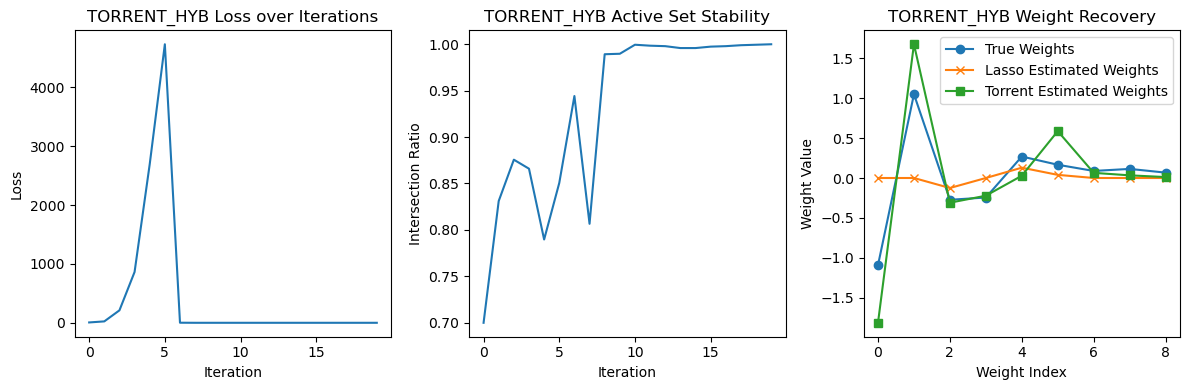

--- Detected Corruption level: 20% ---


,Torrent Regression,Lasso Regression
Recovery Error,1.0752,1.5588
Train MSE,0.2746,0.6482
Train R²,0.7260,0.3532
Test MSE,0.3504,0.6215
Test R²,0.6290,0.3419


In [11]:
# -------- Corruption parameters --------
corruption_fraction = 0.2
corruption_range = [-5,5]

# -------- Model parameters --------
beta = 0.3
lambda_ = 0.1
tol = 1e-8
max_iter = 1000
eta = 0.001
delta_switch = 0.1

run_experiment(corruption_fraction, corruption_range, beta, lambda_, tol, max_iter, eta, delta_switch)

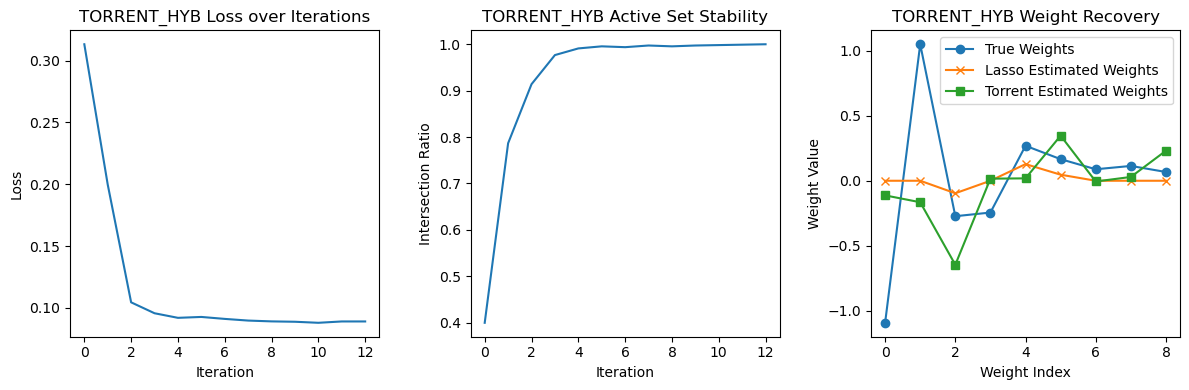

--- Detected Corruption level: 50% ---


,Torrent Regression,Lasso Regression
Recovery Error,1.6653,1.5614
Train MSE,0.3746,0.6724
Train R²,0.6262,0.3291
Test MSE,0.4683,0.6425
Test R²,0.5042,0.3197


In [12]:
# -------- Corruption parameters --------
corruption_fraction = 0.5
corruption_range = [-5,5]

# -------- Model parameters --------
beta = 0.6
lambda_ = 0.1
tol = 1e-8
max_iter = 1000
eta = 0.001
delta_switch = 0.1

run_experiment(corruption_fraction, corruption_range, beta, lambda_, tol, max_iter, eta, delta_switch)